# YOUR PROJECT TITLE

> **Note the following:** 
> 1. This is *not* meant to be an example of an actual **model analysis project**, just an example of how to structure such a project.
> 1. Remember the general advice on structuring and commenting your code
> 1. The `modelproject.py` file includes a function which could be used multiple times in this notebook.

Imports and set magics:

In [116]:
import numpy as np
from scipy import optimize
import sympy as sm
from types import SimpleNamespace
import matplotlib.pyplot as plt
# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# local modules
import modelproject

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Model description

Our project analyses the Overlapping generations (OLG) model. The OLG model is a cornerstone model of modern economics. It investigates intergeneraltional allocation and the life-cycle behavior (investment in human capital, work and saving for retirement). 

In the OLG model, we have 2 periods, one when individuals are young, period 1 and one when they are old, period t+1. 
Induviduals are born in period t.

$$L_t =L_{t+1}(1+n)$$

There are $L_t$ young people and $L_{t+1}$ old people. n is the population growth

**Firms**: We have in the OLG model that firms are competitive, identical and maximize their profits as such:

$$
\begin{aligned}
\pi_t & =\max_{K_{t},L_t} K_t^\alpha L_t^{1-\alpha}-r_tK_t-w_tL_t\\
\end{aligned}
$$
This is a Cobb-Douglas production-function. $K_{t}$ is the capital, $L_t$ is the labor, $\alpha$ is a parameter, $\in (0, 1)$.

We define kapital in per capita terms, and we have that the rent on capital is its marginal product. And the cost of labour is the wage which is also its marginal product.
$$
\begin{aligned}
k_t & =\frac{K_t}{L_t} \\
r_t & = \alpha  k_t^{\alpha-1} \\
w_t & = (1-\alpha)  k_t^{\alpha}
\end{aligned}
$$


The budget constraint for the young and old is: 

$$
c_{1t} + s_t = w_t 
$$

$$
c_{2t+1} = (1 + r_{t+1}) s_t
$$

The young consume their wage and saves for when they are old. The old then get these savings and the interest rate they got on the savings. 

The lifetime budget constraint then becomes:

$$c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = w_t $$

The old consumes all of their remaining saved wages. We see that all consumtion comes from the wage made in period 1. 

Utility for the households is:
    
$$
\begin{aligned}
U_t & = u(c_{1t})+\frac{1}{1+\rho} u(c_{2t+1})\\
\end{aligned}
$$

$\rho$ is the discount rate, i.e. the measure of patience of the households, i.e. how much consumption the househoplds wants when young in period 1 and when old in period 2. A higher $\rho$ means more impatient households, $\rho \in (0,1)$.

We can now solve the households maximization problem:

$$ \max_{c_{1t}, c_{2t+1}} \left( u(c_{1t}) + \frac{1}{1+\rho} u(c_{2t+1}) \right) $$

Subject to the budget constraint:

$$ c_{1t} + \frac{c_{2t+1}}{1+r_{t+1}} = W_t $$

We can now solve this using sympy, and find the OLG-euler.

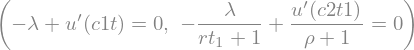

In [117]:
from sympy import symbols, Function, diff, Eq, solve, init_printing

init_printing()

# Symbols
c1t, c2t1, Wt, rt1, rho, lam = symbols('c1t c2t1 Wt rt1 rho lambda')

# Utility functions
u = Function('u')

# Lagrangian
L = u(c1t) + 1 / (1 + rho) * u(c2t1) + lam * (Wt - c1t - c2t1 / (1 + rt1))

# Computing FOC
foc_c1t = diff(u(c1t), c1t) - lam
foc_c2t1 = diff(u(c2t1), c2t1) / (1 + rho) - lam / (1 + rt1)

u_prime_c1t = symbols("u'(c1t)")
u_prime_c2t1 = symbols("u'(c2t1)")
foc_c1t = foc_c1t.subs(diff(u(c1t), c1t), u_prime_c1t)
foc_c2t1 = foc_c2t1.subs(diff(u(c2t1), c2t1), u_prime_c2t1)

# Formatting
eq1 = Eq(foc_c1t, 0)
eq2 = Eq(foc_c2t1, 0)

eq1, eq2

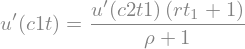

In [118]:
# we solve for lambda from eq1 and substitute in eq2
lambda_from_eq1 = solve(eq1, lam)[0]
euler_eq = eq2.subs(lam, lambda_from_eq1)

# We now solve the Euler equation for u_prime_c1t
euler_solution = solve(euler_eq, u_prime_c1t)

# Formatting
euler_solution_eq = Eq(u_prime_c1t, euler_solution[0])

euler_solution_eq

We have now found the Euler equation for the OLG. If we combine the budget constraints with the euler we can find the optimal savings. 

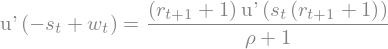

In [119]:
import sympy as sp

# Varibales
wt, st, rt1, rho = sp.symbols('w_t s_t r_{t+1} rho')

c1t = wt - st
c2t1 = (1 + rt1) * st

# We define u' as a function
u_prime = sp.Function('u\'')  

# The euler equation expressed in terms of st and wt
savings_rate = sp.Eq(u_prime(c1t), (1 + rt1) / (1 + rho) * u_prime(c2t1))

savings_rate



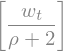

In [120]:
def u_prime(c):
    return 1/c
eq = Eq(u_prime(-st + wt), (rt1 + 1) * u_prime(st * (rt1 + 1)) / (rho + 1))
solution = solve(eq, st)

solution

So the optimal savings rate is: 

$$s_t=1/(2+\rho)wt

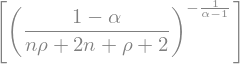

In [121]:
kt, kt1, n, rho, alpha, wt = sp.symbols('k_t k_{t+1} n rho alpha w_t')

#Capital accumulation equation
equation = sp.Eq(kt1 * (1 + n), (1 / (2 + rho)) * (1 - alpha) * kt**alpha)

# We solve for the steady state by setting kt1 = kt
steady_state_eq = equation.subs(kt1, kt)
steady_state_solution = sp.solve(steady_state_eq, kt)

steady_state_solution

We have steady state: 
$$
k^* = \left[ \frac{1 - \alpha}{(1 + n)(2 + \rho)} \right]^{\frac{1}{1-\alpha}}
$$

We can assign numeric values to $ n, \alpha, \rho $

In [122]:
Steady_state_nums = sm.lambdify((rho,alpha,n),steady_state_solution)
Steady_state_nums(0.03, 0.35, 0.02)

For the chosen parameter value, we find that steady state is $k^*=0.168$

We can now set up an algorithm that solves our steady state, we use the bisect method. 

In [123]:
# Setting parameters
rho = 0.03
alpha = 0.35
n = 0.02

kss=((1-alpha)/((1+n)*(2+rho))**1/(1-alpha))

# We define the objective, The function calculates the difference between k and the expression, The goal is to find the value of k for which this difference is zero. 
obj = lambda k: k - (((1-alpha)*k**alpha)/((1+n)*(2+rho)))

# Optimizing the model and finding the roots with bisect
result = optimize.root_scalar(obj,bracket=[1e-10,10],method='bisect') 
result.root

initializing the model:
calling .setup()
calling .allocate()
simulation done in 0.00 secs


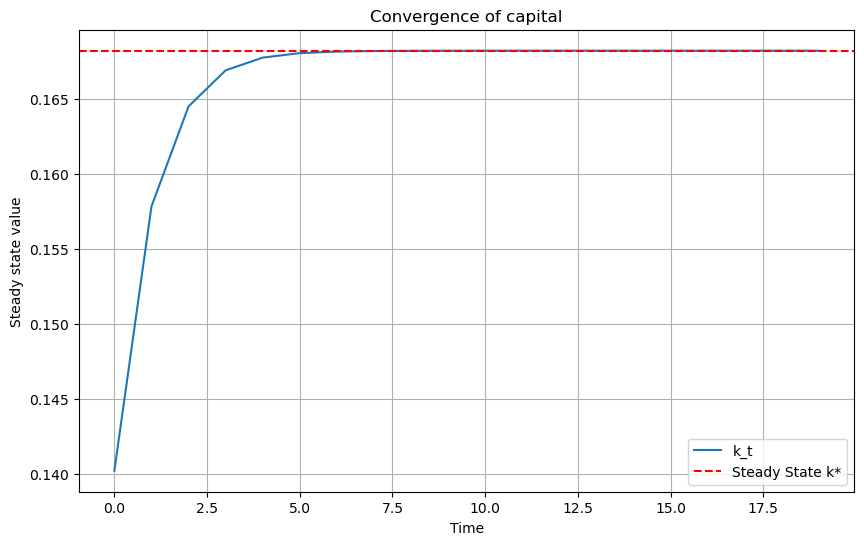

In [124]:
from modelproject import OLGModelClass
model = OLGModelClass()

par = model.par
sim = model.sim

model.simulate()
plt.figure(figsize=(10, 6))
plt.plot(model.sim.k, label='k_t')  # Plotting k_t over time
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

sim_k_original = model.sim.k.copy()

We see that k_t converges to the steady state after about 5 periods. There is convergence to the steady state value we found erlier.

# Further Analysis

We have now found the steady state convergese for paramteter values of $ \alpha, \rho, n $. These values are educated guesses, and we would like to see what would happen with different values. 

In [125]:
# New parameters
par.n=0.04
popchange=Steady_state_nums(0.03, 0.35, 0.05)
model.simulate()

simulation done in 0.00 secs


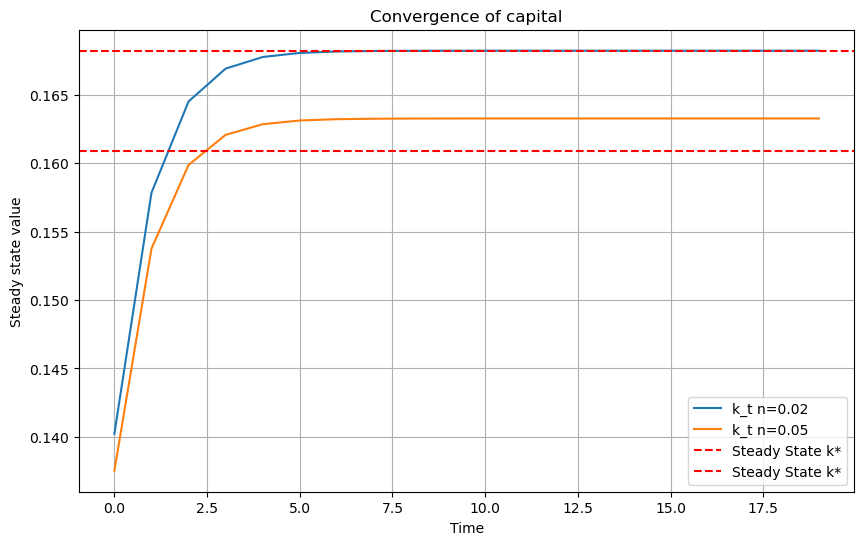

In [126]:
plt.figure(figsize=(10, 6))
plt.plot(sim_k_original, label='k_t n=0.02')
plt.plot(model.sim.k, label='k_t n=0.05') 
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=popchange, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

We see that with a increase in population size, there will be convergense in the same number of periods, but with a lower steady state value.

In [127]:
# New parameters
par.n=0.02
par.alpha=0.4
popchange=Steady_state_nums(0.03, 0.4, 0.02)
model.simulate()

simulation done in 0.00 secs


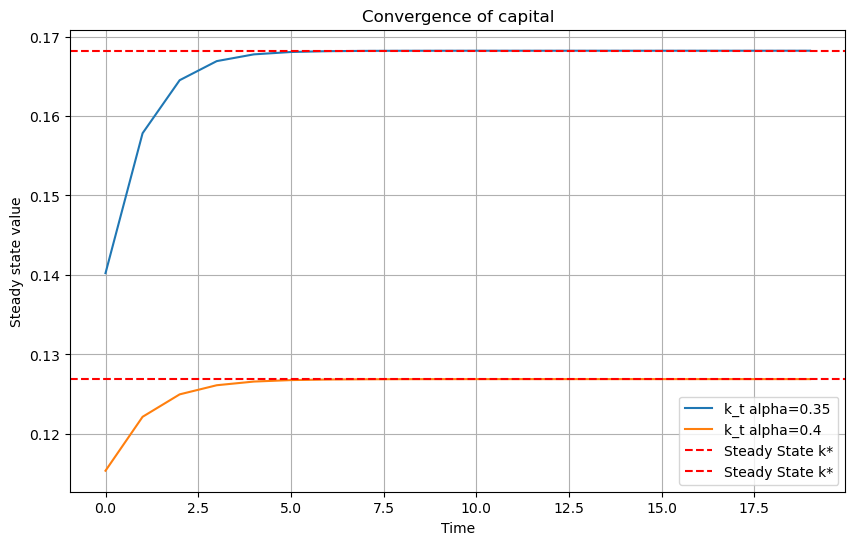

In [128]:
plt.figure(figsize=(10, 6))
plt.plot(sim_k_original, label='k_t alpha=0.35')
plt.plot(model.sim.k, label='k_t alpha=0.4') 
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=popchange, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

An increase of the elasticity of capital, $\alpha$, decreases the steady state value. 

In [129]:
# New parameters
par.alpha=0.35
par.rho=0.05
popchange=Steady_state_nums(0.05, 0.35, 0.02)
model.simulate()

simulation done in 0.00 secs


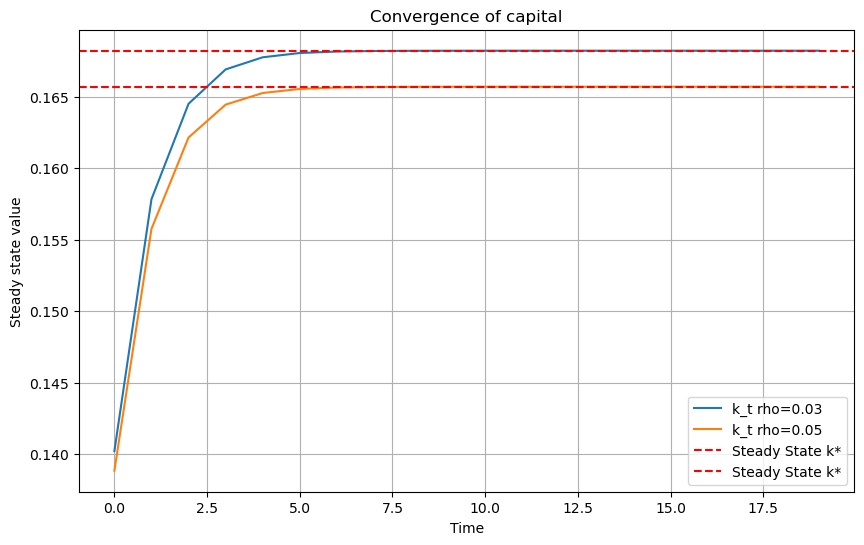

In [130]:
plt.figure(figsize=(10, 6))
plt.plot(sim_k_original, label='k_t rho=0.03')
plt.plot(model.sim.k, label='k_t rho=0.05') 
plt.xlabel('Time')
plt.ylabel('Steady state value')
plt.title('Convergence of capital')
plt.axhline(y=result.root, color='r', linestyle='--', label='Steady State k*')
plt.axhline(y=popchange, color='r', linestyle='--', label='Steady State k*')
plt.legend()
plt.grid(True)
plt.show()

A higher discount rate, $\rho$, decreases the steady stae value of kapital. 

# Conclusion

We saw that we could solve the model using sympy in python. After this we got the same result by numerically solving our staeady state level of kapital and getting an algorith to solve it. In both cases we saw a value of 0.168. We then simulated the model and plottet the steady state capital and saw that in converged in about 5 periods. We also investigated what happened when we used different values of the parameters in the model. Found that

$$ \rho \uparrow = ss_k \downarrow$$
$$ \alpha \uparrow = ss_k \downarrow$$
$$ n \uparrow = ss_k \downarrow$$